# 🎯 Goal:
## Compare Linear Regression, Ridge, Lasso, and ElasticNet on a dataset to see how regularization affects model performance.

# 🧾 Sample Dataset: House Price with Collinearity

In [1]:
import pandas as pd
import numpy as np

# Simulated data
np.random.seed(42)
X1 = np.random.rand(100) * 100
X2 = X1 + np.random.normal(0, 10, 100)  # Highly correlated with X1
X3 = np.random.rand(100) * 50
noise = np.random.normal(0, 25, 100)
y = 3 * X1 + 2 * X2 + 5 * X3 + noise

df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'Price': y
})

# 🧪 Model Training

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

# Features & target
X = df[['X1', 'X2', 'X3']]
y = df['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔧 Training Models

In [3]:
# Models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

# Fit and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    print("R² Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))


LinearRegression
Coefficients: [3.36596518 1.59423303 5.14237888]
Intercept: -0.5117112915152688
R² Score: 0.9815204176968387
MSE: 421.4299224163625

Ridge
Coefficients: [3.36566451 1.59450342 5.14205381]
Intercept: -0.5018085326316282
R² Score: 0.9815195166255583
MSE: 421.450471495536

Lasso
Coefficients: [3.36964914 1.5897732  5.13764382]
Intercept: -0.35557071856300126
R² Score: 0.9815175837678105
MSE: 421.49455063527546

ElasticNet
Coefficients: [3.35799483 1.60073046 5.1271014 ]
Intercept: -0.046772104949809545
R² Score: 0.9814846949059234
MSE: 422.24458655524893


# 📈 Optional: Visual Comparison of Predictions

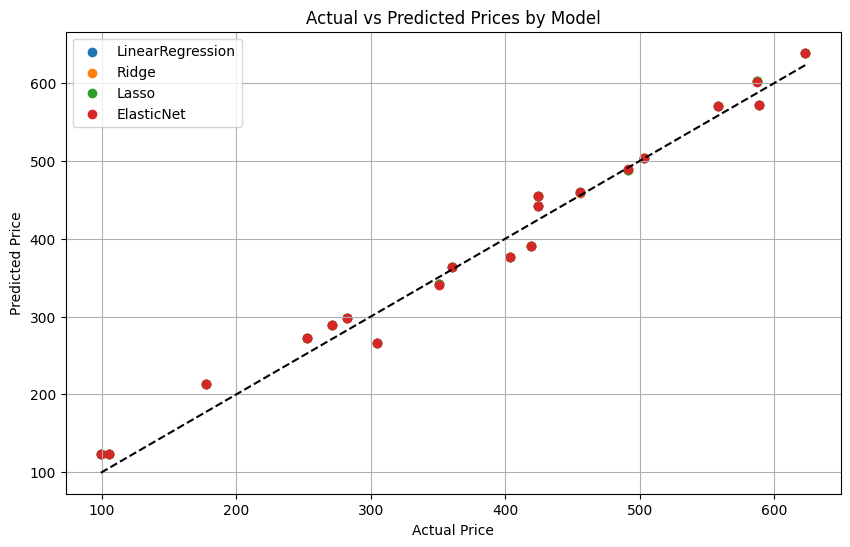

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.scatter(y_test, y_pred, label=name)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices by Model")
plt.legend()
plt.grid(True)
plt.show()